In [2]:
# Cell 1: Imports and deterministic seeds (numpy, torch/TF, PIL, torchvision, sklearn)
# (If you prefer PyTorch, we'll default to PyTorch here)
import os, random, math, json, zipfile, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fastprogress import progress_bar

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# PyTorch imports
import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
import torchvision
from torchvision import transforms
from torchvision import models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
print("Torch", torch.__version__, "CUDA available:", torch.cuda.is_available())


Torch 2.8.0+cu126 CUDA available: True


In [4]:
# Cell 2: Unzip provided archives into workspace and list top files; assert expected counts (assumptions may be adjusted)
# Put your uploaded files into /content or Colab Files (or mount drive and set BASE_DIR)
BASE = Path("/content/drive/MyDrive/UP Honours/COS711 - AI/Assignment 3/Data")
BASE.mkdir(parents=True, exist_ok=True)

# If files are in /mnt/data (from your environment), copy them into working dir
# UPLOAD_DIR = Path("/mnt")  # change if your files are elsewhere
# for fname in ["typ.zip", "exo.zip", "unl.zip", "labels.csv", "test.csv"]:
#     src = UPLOAD_DIR / fname
#     if src.exists():
#         shutil.copy(src, BASE / fname)

# # Unzip if present
# for z in ["typ.zip", "exo.zip", "unl.zip"]:
#     zpath = BASE / z
#     if zpath.exists():
#         with zipfile.ZipFile(zpath, 'r') as zf:
#             zf.extractall(BASE / z.replace('.zip',''))
#     else:
#         print("Warning: missing", zpath)

# Quick counts
typ_count = len(list((BASE/"typ").glob("**/*.*"))) if (BASE/"typ").exists() else None
exo_count = len(list((BASE/"exo").glob("**/*.*"))) if (BASE/"exo").exists() else None
unl_count = len(list((BASE/"unl").glob("**/*.*"))) if (BASE/"unl").exists() else None
print("typ_count:", typ_count, "exo_count:", exo_count, "unl_count:", unl_count)
# show top 5 filenames each
for d in ["typ","exo","unl"]:
    p = BASE / d
    if p.exists():
        print(f"Sample from {d}:", [str(x.name) for x in list(p.glob('*'))[:5]])


typ_count: 2049 exo_count: 72 unl_count: 13821
Sample from typ: ['typ_PNG']
Sample from exo: ['exo_PNG']
Sample from unl: ['unl_PNG']


In [13]:
# Cell 3: Load labels.csv and test.csv; show head and unique labels
labels_path = BASE / "labels.csv"
test_path = BASE / "test.csv"
assert labels_path.exists(), f"{labels_path} not found - upload it to /mnt/data or update path"
labels_df = pd.read_csv(labels_path, header=None, names=["ra", "dec", "label", "col4", "col5"])
print("labels.csv shape:", labels_df.shape)
display(labels_df.head(8))

# Clean up unused columns
labels_df = labels_df[["ra", "dec", "label"]].dropna(subset=["ra","dec","label"])
print("After cleanup:", labels_df.shape)
print("Unique labels:", labels_df["label"].unique())

if test_path.exists():
    test_df = pd.read_csv(test_path)
    print("test.csv shape:", test_df.shape)
    display(test_df.head(6))
else:
    print("test.csv not found; proceed later when uploaded")
# Show unique labels (may be multiple rows per source)
if 'label' in labels_df.columns:
    print("Unique labels:", sorted(labels_df['label'].unique())[:30])
else:
    print("Columns in labels.csv:", labels_df.columns.tolist())

labels.csv shape: (2178, 5)


,ra,dec,label,col4,col5
0,10.328221,-20.476357,FR II,NaN,NaN
1,92.109802,-49.431413,typical,NaN,NaN
2,88.916825,-59.431868,Point Source,NaN,NaN
3,5.457981,-25.589637,FR II,NaN,NaN
4,119.417608,-53.396711,FR II,NaN,NaN
5,144.100249,-76.517079,Bent,NaN,NaN
6,212.307137,-42.897881,Bent,NaN,NaN
7,108.108297,-60.170606,Point Source,NaN,NaN


After cleanup: (2178, 3)
Unique labels: ['FR II' 'typical' 'Point Source' 'Bent' 'Should be discarded' 'FR I'
 'Exotic' 'S/Z shaped' 'X-Shaped']
test.csv shape: (99, 2)


,201.7436567,-31.32163727
0,234.261286,-46.590846
1,66.793081,-62.375058
2,108.760518,-59.958776
3,202.148240,-31.432391
4,57.025208,-73.861150
5,216.316836,-54.750811


Unique labels: ['Bent', 'Exotic', 'FR I', 'FR II', 'Point Source', 'S/Z shaped', 'Should be discarded', 'X-Shaped', 'typical']


In [8]:
# ✅ Drop 'Should be discarded' and clean label text
labels_df = labels_df[labels_df["label"].str.lower().str.contains("discard") == False]

# Standardize label casing and spacing
labels_df["label"] = (
    labels_df["label"]
    .str.strip()
    .str.replace("-", " ", regex=False)
    .str.replace("/", " ", regex=False)
    .str.title()
)

# Verify
print("Cleaned labels count:", len(labels_df))
print("Unique cleaned labels:", sorted(labels_df["label"].unique()))
display(labels_df.head(8))


Cleaned labels count: 2048
Unique cleaned labels: ['Bent', 'Exotic', 'Fr I', 'Fr Ii', 'Point Source', 'S Z Shaped', 'Typical', 'X Shaped']


,ra,dec,label
0,10.328221,-20.476357,Fr Ii
1,92.109802,-49.431413,Typical
2,88.916825,-59.431868,Point Source
3,5.457981,-25.589637,Fr Ii
4,119.417608,-53.396711,Fr Ii
5,144.100249,-76.517079,Bent
6,212.307137,-42.897881,Bent
7,108.108297,-60.170606,Point Source


In [24]:
# Inspect structure to see where real images live
!find f"{BASE}" -maxdepth 3 -type d


find: ‘f/content/drive/MyDrive/UP Honours/COS711 - AI/Assignment 3/Data’: No such file or directory


In [22]:
print(BASE)

/content/drive/MyDrive/UP Honours/COS711 - AI/Assignment 3/Data


In [29]:
# Recursive image search under typ_PNG/exo_PNG/unl_PNG folders
import re
import pandas as pd
from pathlib import Path

def extract_coords_from_filename(fname):
    """Extract first two floats (RA, Dec) from filename."""
    name = Path(fname).stem
    nums = re.findall(r"-?\d+\.\d+", name)
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    # fallback for integer coords (unlikely here)
    nums = re.findall(r"-?\d+", name)
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return None

images = []
for subset in ["typ", "exo"]:
    subset_path = BASE / subset
    # 🔍 recursively search all common image extensions
    for f in subset_path.rglob("*"):
        if f.suffix.lower() in [".png", ".jpg", ".jpeg", ".tif", ".tiff"] and f.is_file():
            coords = extract_coords_from_filename(f.name)
            images.append({
                "filename": str(f),
                "subset": subset,
                "fname": f.name,
                "coords": coords
            })

images_df = pd.DataFrame(images)
print(f"Extracted coords for {len(images_df)} images")
print(images_df.head(8))


Extracted coords for 2120 images
                                            filename subset  \
0  /content/drive/MyDrive/UP Honours/COS711 - AI/...    typ   
1  /content/drive/MyDrive/UP Honours/COS711 - AI/...    typ   
2  /content/drive/MyDrive/UP Honours/COS711 - AI/...    typ   
3  /content/drive/MyDrive/UP Honours/COS711 - AI/...    typ   
4  /content/drive/MyDrive/UP Honours/COS711 - AI/...    typ   
5  /content/drive/MyDrive/UP Honours/COS711 - AI/...    typ   
6  /content/drive/MyDrive/UP Honours/COS711 - AI/...    typ   
7  /content/drive/MyDrive/UP Honours/COS711 - AI/...    typ   

                                               fname              coords  
0  342.797 -15.635_[0.02266963 0.02266963] deg_(A...  (342.797, -15.635)  
1  10.285 -20.344_[0.009 0.009] deg_(Abell_2813_1...   (10.285, -20.344)  
2  355.513 -8.215_[0.02581574 0.02581574] deg_(Ab...   (355.513, -8.215)  
3  7.519 -18.552_[0.01221271 0.01221271] deg_(Abe...    (7.519, -18.552)  
4  20.516 -26.817_[0.009

In [34]:
# Cell 5: Map label coordinates to closest image file by Euclidean distance in coordinate space
# - Assumes labels.csv has two columns for coords called like 'coord1','coord2' or the first two columns are coords.
lab = labels_df.copy()
# heuristics to find coord columns
cols = lab.columns.tolist()
coord_cols = None
for c0 in cols[:3]:
    for c1 in cols[:3]:
        if c0!=c1:
            try:
                _ = lab[[c0,c1]].astype(float)
                coord_cols = (c0,c1)
                break
            except:
                continue
    if coord_cols:
        break
assert coord_cols is not None, f"Could not find numeric coordinate columns in labels.csv; columns: {cols}"
lab = lab.rename(columns={coord_cols[0]:'ra', coord_cols[1]:'dec'})
lab['ra'] = lab['ra'].astype(float)
lab['dec'] = lab['dec'].astype(float)

# Filter out hidden checkpoint or system files before building KDTree
images_df = images_df[~images_df['filename'].str.contains('.ipynb_checkpoints')]
images_df = images_df[images_df['filename'].str.lower().str.endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
print("Filtered images_df length:", len(images_df))

# Build KDTree on images that had coords extracted
coords_list = [c for c in images_df['coords'] if c is not None]
img_index = images_df[images_df['coords'].notnull()].reset_index(drop=True)
from scipy.spatial import cKDTree
tree = cKDTree(np.vstack(img_index['coords'].values))
matches=[]
for i,row in lab.iterrows():
    r,d = row['ra'], row['dec']
    dist, idx = tree.query([r,d], k=1)
    matched = img_index.loc[idx, 'filename']
    matches.append(matched)
lab['matched_filename'] = matches
display(lab.head(8))
# merge to get label lists per filename
grouped = lab.groupby('matched_filename')['label'].apply(lambda x: list(x.unique())).reset_index()
grouped.head(6)


Filtered images_df length: 2107


,ra,dec,label,matched_filename
0,10.328221,-20.476357,FR II,/content/drive/MyDrive/UP Honours/COS711 - AI/...
1,92.109802,-49.431413,typical,/content/drive/MyDrive/UP Honours/COS711 - AI/...
2,88.916825,-59.431868,Point Source,/content/drive/MyDrive/UP Honours/COS711 - AI/...
3,5.457981,-25.589637,FR II,/content/drive/MyDrive/UP Honours/COS711 - AI/...
4,119.417608,-53.396711,FR II,/content/drive/MyDrive/UP Honours/COS711 - AI/...
5,144.100249,-76.517079,Bent,/content/drive/MyDrive/UP Honours/COS711 - AI/...
6,212.307137,-42.897881,Bent,/content/drive/MyDrive/UP Honours/COS711 - AI/...
7,108.108297,-60.170606,Point Source,/content/drive/MyDrive/UP Honours/COS711 - AI/...


,matched_filename,label
0,/content/drive/MyDrive/UP Honours/COS711 - AI/...,[Exotic]
1,/content/drive/MyDrive/UP Honours/COS711 - AI/...,[Exotic]
2,/content/drive/MyDrive/UP Honours/COS711 - AI/...,[Exotic]
3,/content/drive/MyDrive/UP Honours/COS711 - AI/...,[Exotic]
4,/content/drive/MyDrive/UP Honours/COS711 - AI/...,[Bent]
5,/content/drive/MyDrive/UP Honours/COS711 - AI/...,[S/Z shaped]


In [35]:
# Cell 6: Create final labeled dataframe with multi-label binarizer and show class counts
merged = img_index.merge(grouped, left_on='filename', right_on='matched_filename', how='left')
merged['label'] = merged['label'].apply(lambda x: x if isinstance(x,list) else [])
mlb = MultiLabelBinarizer(sparse_output=False)
Y = mlb.fit_transform(merged['label'])
label_classes = mlb.classes_.tolist()
print("Classes:", label_classes)
class_counts = Y.sum(axis=0)
print("Class counts:\n", dict(zip(label_classes, class_counts)))
merged['labels_list'] = merged['label']
merged['multi_hot'] = list(Y)
display(merged.head(6))
# assertion: at least 50 labeled examples exist
assert merged.shape[0] > 10, "Too few labeled images found; check mapping step."


Classes: ['Bent', 'Exotic', 'FR I', 'FR II', 'Point Source', 'S/Z shaped', 'Should be discarded', 'X-Shaped', 'typical']
Class counts:
 {'Bent': np.int64(423), 'Exotic': np.int64(18), 'FR I': np.int64(428), 'FR II': np.int64(674), 'Point Source': np.int64(429), 'S/Z shaped': np.int64(17), 'Should be discarded': np.int64(109), 'X-Shaped': np.int64(5), 'typical': np.int64(24)}


,filename,subset,fname,coords,matched_filename,label,labels_list,multi_hot
0,/content/drive/MyDrive/UP Honours/COS711 - AI/...,typ,342.797 -15.635_[0.02266963 0.02266963] deg_(A...,"(342.797, -15.635)",/content/drive/MyDrive/UP Honours/COS711 - AI/...,[FR II],[FR II],"[0, 0, 0, 1, 0, 0, 0, 0, 0]"
1,/content/drive/MyDrive/UP Honours/COS711 - AI/...,typ,10.285 -20.344_[0.009 0.009] deg_(Abell_2813_1...,"(10.285, -20.344)",/content/drive/MyDrive/UP Honours/COS711 - AI/...,"[FR I, Point Source]","[FR I, Point Source]","[0, 0, 1, 0, 1, 0, 0, 0, 0]"
2,/content/drive/MyDrive/UP Honours/COS711 - AI/...,typ,355.513 -8.215_[0.02581574 0.02581574] deg_(Ab...,"(355.513, -8.215)",/content/drive/MyDrive/UP Honours/COS711 - AI/...,[FR II],[FR II],"[0, 0, 0, 1, 0, 0, 0, 0, 0]"
3,/content/drive/MyDrive/UP Honours/COS711 - AI/...,typ,7.519 -18.552_[0.01221271 0.01221271] deg_(Abe...,"(7.519, -18.552)",/content/drive/MyDrive/UP Honours/COS711 - AI/...,[FR I],[FR I],"[0, 0, 1, 0, 0, 0, 0, 0, 0]"
4,/content/drive/MyDrive/UP Honours/COS711 - AI/...,typ,20.516 -26.817_[0.009 0.009] deg_(Abell_2895_1...,"(20.516, -26.817)",/content/drive/MyDrive/UP Honours/COS711 - AI/...,[Point Source],[Point Source],"[0, 0, 0, 0, 1, 0, 0, 0, 0]"
5,/content/drive/MyDrive/UP Honours/COS711 - AI/...,typ,65.296 -56.123_[0.02035678 0.02035678] deg_(J0...,"(65.296, -56.123)",/content/drive/MyDrive/UP Honours/COS711 - AI/...,[FR II],[FR II],"[0, 0, 0, 1, 0, 0, 0, 0, 0]"


In [51]:
# Cell 7: Train/val split (deterministic) and small DataLoader definition for debugging
from torch.utils.data import Dataset, DataLoader
IMG_SIZE = 224
BATCH = 32

# Basic transforms for debugging — real training uses augmentations
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

from PIL import Image, UnidentifiedImageError

class RadioDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['filename']
        try:
            img = Image.open(img_path).convert('RGB')
        except (UnidentifiedImageError, OSError) as e:
            # print(f"Skipping corrupted image: {img_path} ({e})")
            # Skip and try next item (wrap around to avoid IndexError)
            return self.__getitem__((idx + 1) % len(self.df))
        if self.transform:
            img = self.transform(img)
        target = torch.tensor(row['multi_hot'], dtype=torch.float32)
        return img, target

train_df, val_df = train_test_split(merged, test_size=0.15, random_state=SEED, stratify=None)
print("train:", len(train_df), "val:", len(val_df))
# quick loader
train_loader = DataLoader(
    RadioDataset(train_df, basic_transform),
    batch_size=min(BATCH, len(train_df)),
    shuffle=True
)
imgs, targets = next(iter(train_loader))
print("Batch imgs:", imgs.shape, "targets:", targets.shape)

train: 1790 val: 317
Batch imgs: torch.Size([32, 3, 224, 224]) targets: torch.Size([32, 9])


In [40]:
# Cell 8: Build a simple transfer-learning model (EfficientNet or ResNet) for multi-label classification
import torch.nn as nn

n_classes = len(label_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# using resnet50 as default
backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
# replace final layer
in_features = backbone.fc.in_features
backbone.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, n_classes)
)
model = backbone.to(device)
print("Model ready with output dim", n_classes)
# quick forward pass to ensure no error
model.eval()
with torch.no_grad():
    out = model(imgs.to(device))
    print("Forward output shape:", out.shape)


Model ready with output dim 9
Forward output shape: torch.Size([32, 9])


In [41]:
# Cell 9: Training loop (single epoch quick run) with assertions and checkpoint save
# - This is a short smoke-test training loop; for full training set epochs increase epochs.
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scaler = GradScaler()
EPOCHS = 1

def train_one_epoch(loader, model, opt, crit, device, scaler):
    model.train()
    total_loss = 0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        with autocast():
            logits = model(x)
            loss = crit(logits, y)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

history = {}
history['train_loss'] = train_one_epoch(train_loader, model, optimizer, criterion, device, scaler)
print("Train loss (smoke):", history['train_loss'])
# save smoke checkpoint
torch.save(model.state_dict(), "/content/drive/MyDrive/UP Honours/COS711 - AI/Results/model_smoke.pth")
print("Saved /content/drive/MyDrive/UP Honours/COS711 - AI/Results/model_smoke.pth")


/tmp/ipython-input-1552244078.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1552244078.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Skipping corrupted image: /content/drive/MyDrive/UP Honours/COS711 - AI/Assignment 3/Data/typ/typ_PNG/69.886 -61.132_[0.01131575 0.01131575] deg_(J0431.4-6126.Fix.1pln-forPyBDSF.FITS).fits.png (cannot identify image file '/content/drive/MyDrive/UP Honours/COS711 - AI/Assignment 3/Data/typ/typ_PNG/69.886 -61.132_[0.01131575 0.01131575] deg_(J0431.4-6126.Fix.1pln-forPyBDSF.FITS).fits.png')
Train loss (smoke): 0.36079109985402175
Saved /content/drive/MyDrive/UP Honours/COS711 - AI/Results/model_smoke.pth


In [42]:
# Cell 10: Inference on unlabeled images — produce probabilities and prepare for pseudo-labelling
# - Runs model in eval mode on unlabeled dir; writes CSV with top probabilities
model.eval()
unl_dir = BASE / "unl/unl_PNG"
unl_files = sorted([str(f) for f in unl_dir.glob("*")])
print("Unlabeled files count:", len(unl_files))
unl_transform = basic_transform
batch_size = 64
preds = []
filenames = []
with torch.no_grad():
    for i in range(0, len(unl_files), batch_size):
        batch_files = unl_files[i:i+batch_size]
        imgs = []
        for f in batch_files:
            imgs.append(unl_transform(Image.open(f).convert('RGB')))
        imgs = torch.stack(imgs).to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds.append(probs)
        filenames.extend(batch_files)
preds = np.vstack(preds)
df_unl_preds = pd.DataFrame(preds, columns=label_classes)
df_unl_preds['filename'] = filenames
df_unl_preds.to_csv("/content/drive/MyDrive/UP Honours/COS711 - AI/Results/unl_preds.csv", index=False)
print("Saved /content/drive/MyDrive/UP Honours/COS711 - AI/Results/unl_preds.csv with shape", df_unl_preds.shape)
display(df_unl_preds.head())


Unlabeled files count: 13821
Saved /content/drive/MyDrive/UP Honours/COS711 - AI/Results/unl_preds.csv with shape (13821, 10)


,Bent,Exotic,FR I,FR II,Point Source,S/Z shaped,Should be discarded,X-Shaped,typical,filename
0,0.258766,0.004263,0.062534,0.620942,0.010781,0.004356,0.010596,0.004466,0.004256,/content/drive/MyDrive/UP Honours/COS711 - AI/...
1,0.174629,0.009449,0.268604,0.393610,0.078712,0.013877,0.035072,0.009571,0.012625,/content/drive/MyDrive/UP Honours/COS711 - AI/...
2,0.155377,0.011720,0.203733,0.442163,0.076366,0.010577,0.029483,0.012056,0.011395,/content/drive/MyDrive/UP Honours/COS711 - AI/...
3,0.180946,0.010930,0.235551,0.423272,0.034608,0.012570,0.031339,0.009444,0.011739,/content/drive/MyDrive/UP Honours/COS711 - AI/...
4,0.269988,0.013874,0.280161,0.313229,0.042939,0.012491,0.037761,0.013573,0.017579,/content/drive/MyDrive/UP Honours/COS711 - AI/...


In [43]:
# Cell 11: Pseudo-label selection — apply a confidence threshold and create generated_labels.csv
# - Thresholds per class can be tuned; default global 0.95 for high precision
THRESH = 0.95
selected = []
for idx,row in df_unl_preds.iterrows():
    probs = row[label_classes].values
    high_idx = np.where(probs >= THRESH)[0]
    if len(high_idx)>0:
        labels = [label_classes[i] for i in high_idx]
        # extract coords from filename to create output format
        fname = Path(row['filename']).name
        coords = extract_coords_from_filename(fname)
        if coords is None:
            coord1 = coord2 = ""
        else:
            coord1, coord2 = coords
        selected.append({'coord1':coord1, 'coord2':coord2, 'labels':";".join(labels), 'filename': fname})
pseudo_df = pd.DataFrame(selected)
print("Pseudo-labelled rows:", len(pseudo_df))
pseudo_df.head()
# Save final (but this is just high-confidence subset). Full generated_labels.csv must include every unlabeled file eventually.
pseudo_df.to_csv("/content/drive/MyDrive/UP Honours/COS711 - AI/Results/pseudo_labels_highconf.csv", index=False)
print("Saved /content/drive/MyDrive/UP Honours/COS711 - AI/Results/pseudo_labels_highconf.csv")


Pseudo-labelled rows: 0
Saved /content/drive/MyDrive/UP Honours/COS711 - AI/Results/pseudo_labels_highconf.csv


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tmp/ipython-input-1209916661.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_classes, y=roc_aucs, palette="viridis", ax=axes[0, 0])
/tmp/ipython-input-1209916661.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(label_classes, rotation=45, ha="right")


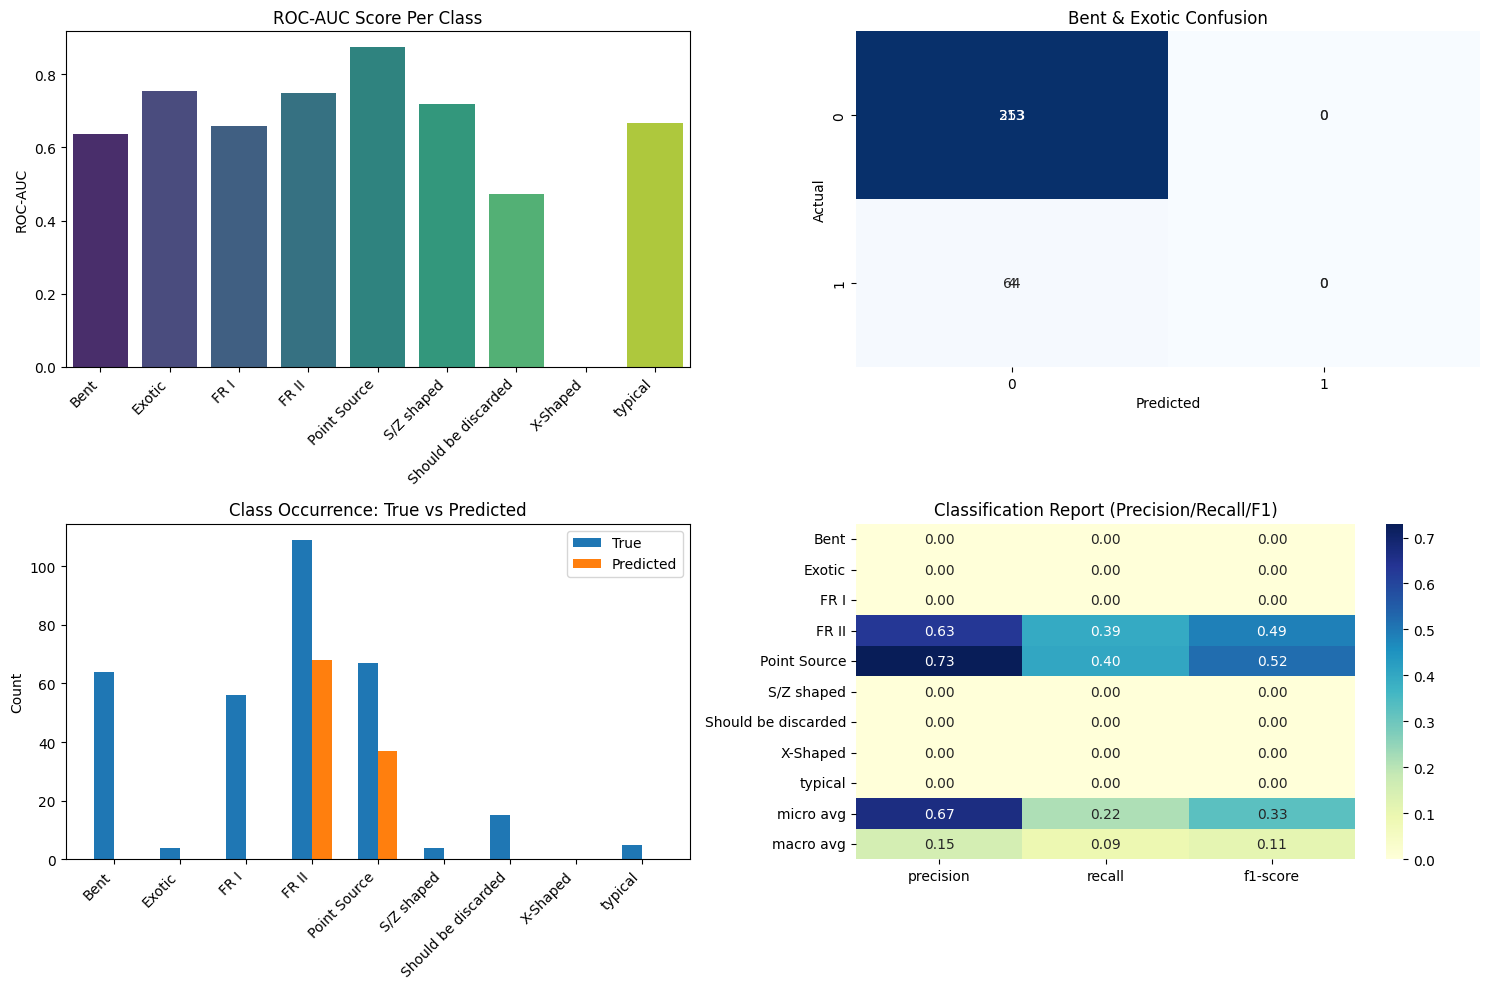

In [46]:
# Cell 12: Performance Visualizations for Multi-Label Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, multilabel_confusion_matrix, classification_report
import numpy as np

val_loader = DataLoader(
    RadioDataset(val_df, basic_transform),
    batch_size=min(BATCH, len(val_df)),
    shuffle=False
)

# Setup
model.eval()
y_true = []
y_pred_logits = []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs, targets = imgs.to(device), targets.cpu().numpy()
        logits = model(imgs).cpu().numpy()
        y_true.append(targets)
        y_pred_logits.append(logits)

y_true = np.vstack(y_true)
y_pred_proba = 1 / (1 + np.exp(-np.vstack(y_pred_logits)))
y_pred = (y_pred_proba > 0.5).astype(int)

# Build a 2x2 grid for nice layout
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# 1. ROC-AUC per class
roc_aucs = [roc_auc_score(y_true[:,i], y_pred_proba[:,i]) for i in range(y_true.shape[1])]
sns.barplot(x=label_classes, y=roc_aucs, palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("ROC-AUC Score Per Class")
axes[0, 0].set_ylabel("ROC-AUC")
axes[0, 0].set_xticklabels(label_classes, rotation=45, ha="right")

# 2. First Confusion Matrix (or as many as fit horizontally)
mcm = multilabel_confusion_matrix(y_true, y_pred)
for i in range(min(2, y_true.shape[1])):
    sns.heatmap(mcm[i], annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, 1 if i==1 else 1])
axes[0, 1].set_title(f"{label_classes[0]} & {label_classes[1]} Confusion" if y_true.shape[1] > 1 else f"{label_classes[0]} Confusion")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Actual")

# 3. Class frequency True vs Predicted
true_counts = y_true.sum(axis=0)
pred_counts = y_pred.sum(axis=0)
X = np.arange(len(label_classes))
axes[1, 0].bar(X-0.15, true_counts, width=0.3, label="True")
axes[1, 0].bar(X+0.15, pred_counts, width=0.3, label="Predicted")
axes[1, 0].set_xticks(X)
axes[1, 0].set_xticklabels(label_classes, rotation=45, ha='right')
axes[1, 0].set_title("Class Occurrence: True vs Predicted")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()

# 4. Classification Report heatmap
from pandas import DataFrame
report = classification_report(y_true, y_pred, target_names=label_classes, output_dict=True, zero_division=0)
df_report = DataFrame(report).transpose()
sns.heatmap(df_report.iloc[:-2, :-1], annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1, 1])
axes[1, 1].set_title("Classification Report (Precision/Recall/F1)")

plt.tight_layout()
plt.show()


/tmp/ipython-input-1736102103.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Skipping corrupted image: /content/drive/MyDrive/UP Honours/COS711 - AI/Assignment 3/Data/typ/typ_PNG/69.886 -61.132_[0.01131575 0.01131575] deg_(J0431.4-6126.Fix.1pln-forPyBDSF.FITS).fits.png (cannot identify image file '/content/drive/MyDrive/UP Honours/COS711 - AI/Assignment 3/Data/typ/typ_PNG/69.886 -61.132_[0.01131575 0.01131575] deg_(J0431.4-6126.Fix.1pln-forPyBDSF.FITS).fits.png')
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 170MB/s]


Skipping corrupted image: /content/drive/MyDrive/UP Honours/COS711 - AI/Assignment 3/Data/typ/typ_PNG/69.886 -61.132_[0.01131575 0.01131575] deg_(J0431.4-6126.Fix.1pln-forPyBDSF.FITS).fits.png (cannot identify image file '/content/drive/MyDrive/UP Honours/COS711 - AI/Assignment 3/Data/typ/typ_PNG/69.886 -61.132_[0.01131575 0.01131575] deg_(J0431.4-6126.Fix.1pln-forPyBDSF.FITS).fits.png')
ResNet50    | Train loss: 0.3686 | Val Acc: 0.196
EffNetV2-S  | Train loss: 0.4316 | Val Acc: 0.246
Model with higher Val Acc is better!


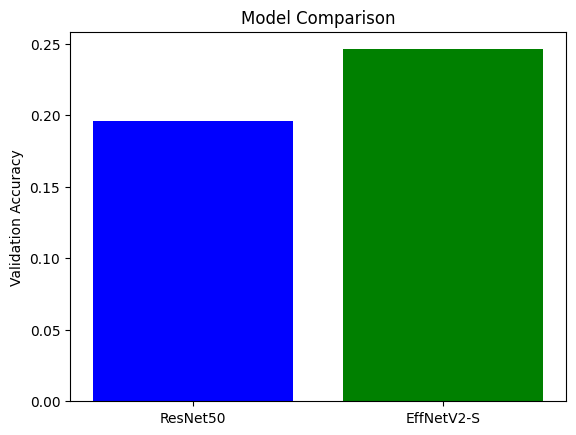

In [49]:
# Cell 13: Setup + Imports for comparison of EfficientNetV2 and RestNet

import torch
import torch.nn as nn
from torchvision import models
from torch.optim import AdamW
from torch.cuda.amp import autocast

try:
    from torch.amp import GradScaler
    scaler = GradScaler(device='cuda')
except ImportError:
    from torch.cuda.amp import GradScaler
    scaler = GradScaler()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nclasses = len(label_classes)  # Use your MultiLabelBinarizer classes

# 1: Define Model Wrappers (compatible with torchvision 0.13+ and below)
def get_resnet50(nclasses):
    try:
        # Try new 'weights' API (torchvision >=0.13)
        backbone = models.resnet50(weights="IMAGENET1K_V2")
    except TypeError:
        # Fallback for legacy API
        backbone = models.resnet50(pretrained=True)
    in_features = backbone.fc.in_features
    backbone.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, nclasses)
    )
    return backbone.to(device)

def get_efficientnetv2(nclasses):
    try:
        backbone = models.efficientnet_v2_s(weights="IMAGENET1K_V1")
    except TypeError:
        backbone = models.efficientnet_v2_s(pretrained=True)
    in_features = backbone.classifier[1].in_features
    backbone.classifier[1] = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, nclasses)
    )
    return backbone.to(device)

# 2. Training/Evaluation Helper Functions
def train_one_epoch(loader, model, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with autocast():
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def evaluate(loader, model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.sigmoid(logits) > 0.5
            correct += (preds == y.bool()).all(dim=1).sum().item()
            total += x.size(0)
    return correct / total if total > 0 else 0

# 3. Run and Compare Models (provide your own trainloader/valloader)
criterion = nn.BCEWithLogitsLoss()

# ResNet50
resnet_model = get_resnet50(nclasses)
optimizer_resnet = AdamW(resnet_model.parameters(), lr=1e-4, weight_decay=1e-5)
train_loss_resnet = train_one_epoch(train_loader, resnet_model, optimizer_resnet, criterion, scaler)
val_acc_resnet = evaluate(val_loader, resnet_model)

# EfficientNetV2
efficientnet_model = get_efficientnetv2(nclasses)
optimizer_efficientnet = AdamW(efficientnet_model.parameters(), lr=1e-4, weight_decay=1e-5)
train_loss_efficientnet = train_one_epoch(train_loader, efficientnet_model, optimizer_efficientnet, criterion, scaler)
val_acc_efficientnet = evaluate(val_loader, efficientnet_model)

print(f"ResNet50    | Train loss: {train_loss_resnet:.4f} | Val Acc: {val_acc_resnet:.3f}")
print(f"EffNetV2-S  | Train loss: {train_loss_efficientnet:.4f} | Val Acc: {val_acc_efficientnet:.3f}")
print("Model with higher Val Acc is better!")

import matplotlib.pyplot as plt
names = ["ResNet50", "EffNetV2-S"]
accs = [val_acc_resnet, val_acc_efficientnet]
plt.bar(names, accs, color=["blue", "green"])
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.show()


/tmp/ipython-input-1348925131.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 | Val Acc: 0.1672
Epoch 2 | Val Acc: 0.3060
Epoch 3 | Val Acc: 0.1672
Epoch 4 | Val Acc: 0.3880
Epoch 5 | Val Acc: 0.3817
Epoch 6 | Val Acc: 0.4069
Epoch 7 | Val Acc: 0.3596
Epoch 8 | Val Acc: 0.4479
Epoch 9 | Val Acc: 0.4543
Epoch 10 | Val Acc: 0.4700
Epoch 11 | Val Acc: 0.4574
Epoch 12 | Val Acc: 0.4385
Epoch 13 | Val Acc: 0.4606
Epoch 14 | Val Acc: 0.4574
Epoch 15 | Val Acc: 0.3975
Epoch 16 | Val Acc: 0.3975
Epoch 17 | Val Acc: 0.3912
Early stopping at epoch 17 (patience triggered).
Epoch 1 | Val Acc: 0.2839
Epoch 2 | Val Acc: 0.3218
Epoch 3 | Val Acc: 0.3155
Epoch 4 | Val Acc: 0.4227
Epoch 5 | Val Acc: 0.3785
Epoch 6 | Val Acc: 0.4448
Epoch 7 | Val Acc: 0.4732
Epoch 8 | Val Acc: 0.4826
Epoch 9 | Val Acc: 0.5237
Epoch 10 | Val Acc: 0.5142
Epoch 11 | Val Acc: 0.4953
Epoch 12 | Val Acc: 0.4826
Epoch 13 | Val Acc: 0.4858
Epoch 14 | Val Acc: 0.4606
Epoch 15 | Val Acc: 0.4700
Epoch 16 | Val Acc: 0.4385
Early stopping at epoch 16 (patience triggered).
ResNet50 Best Val Acc: 0.4700

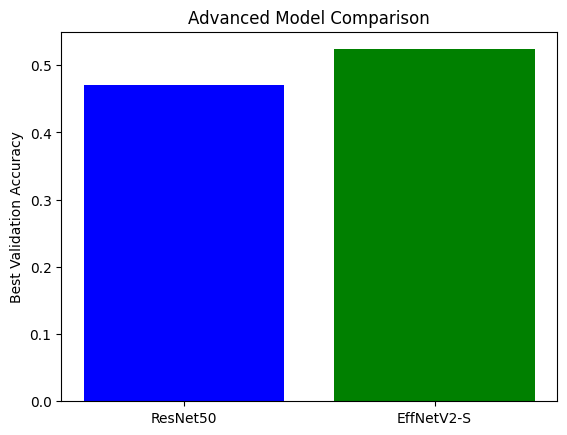

In [52]:
# Cell 14: Advanced Transfer Learning for Image Classification

# Advanced Data Augmentation:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

# Redefine dataset loaders using these transforms if needed.

# Cosine Annealing Learning Rate Scheduler

from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

def get_optimizer_scheduler(model):
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-5)
    return optimizer, scheduler

# Early Stopping Utility
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_acc = None
        self.num_bad_epochs = 0
    def step(self, epoch_acc):
        if self.best_acc is None or epoch_acc > self.best_acc + self.min_delta:
            self.best_acc = epoch_acc
            self.num_bad_epochs = 0
        else:
            self.num_bad_epochs += 1
        return self.num_bad_epochs >= self.patience

# Main Training Loop with Scheduler and Early Stopping
def train_advanced(loader, model, optimizer, criterion, scheduler, val_loader, n_epochs=30):
    scaler = GradScaler()
    stopper = EarlyStopping(patience=7)
    best_val_acc = 0.0
    for epoch in range(n_epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with autocast():
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        scheduler.step()
        val_acc = evaluate(val_loader, model)
        print(f"Epoch {epoch+1} | Val Acc: {val_acc:.4f}")
        if stopper.step(val_acc):
            print(f"Early stopping at epoch {epoch+1} (patience triggered).")
            break
        if val_acc > best_val_acc:
            best_val_acc = val_acc
    return best_val_acc

# Run for Both Models
# ResNet50
resnet_model = get_resnet50(nclasses)
optimizer_r, scheduler_r = get_optimizer_scheduler(resnet_model)
best_val_r = train_advanced(train_loader, resnet_model, optimizer_r, criterion, scheduler_r, val_loader, n_epochs=30)

# EfficientNetV2
efficientnet_model = get_efficientnetv2(nclasses)
optimizer_e, scheduler_e = get_optimizer_scheduler(efficientnet_model)
best_val_e = train_advanced(train_loader, efficientnet_model, optimizer_e, criterion, scheduler_e, val_loader, n_epochs=30)

print(f"ResNet50 Best Val Acc: {best_val_r:.4f}")
print(f"EffNetV2 Best Val Acc: {best_val_e:.4f}")
print("Best result (higher accuracy) wins!")

# Bar chart for advanced comparison
names = ["ResNet50", "EffNetV2-S"]
accs = [best_val_r, best_val_e]
plt.bar(names, accs, color=["blue", "green"])
plt.ylabel("Best Validation Accuracy")
plt.title("Advanced Model Comparison")
plt.show()

--- Setting up all final output directories ---
Directory created/ensured: /content/drive/MyDrive/UP Honours/COS711 - AI/Results/Final outputs/Initial_ResNet50
Directory created/ensured: /content/drive/MyDrive/UP Honours/COS711 - AI/Results/Final outputs/Initial_EfficientNetV2
Directory created/ensured: /content/drive/MyDrive/UP Honours/COS711 - AI/Results/Final outputs/Advanced_ResNet50
Directory created/ensured: /content/drive/MyDrive/UP Honours/COS711 - AI/Results/Final outputs/Advanced_EfficientNetV2

--- Recreating 'Initial' model states by running one epoch of training ---


/tmp/ipython-input-1736102103.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Recreated state for 'Initial_ResNet50'.
Recreated state for 'Initial_EfficientNetV2'.

--- Processing files for model: Initial_ResNet50 ---
Saved 'Initial_ResNet50/generated_labels.csv'
Saved 'Initial_ResNet50/test_labels.csv'

--- Processing files for model: Initial_EfficientNetV2 ---
Saved 'Initial_EfficientNetV2/generated_labels.csv'
Saved 'Initial_EfficientNetV2/test_labels.csv'

--- Processing files for model: Advanced_ResNet50 ---
Saved 'Advanced_ResNet50/generated_labels.csv'
Saved 'Advanced_ResNet50/test_labels.csv'

--- Processing files for model: Advanced_EfficientNetV2 ---
Saved 'Advanced_EfficientNetV2/generated_labels.csv'
Saved 'Advanced_EfficientNetV2/test_labels.csv'

--- Generating and saving final comparison chart using stored accuracy values ---
Saved final comparison chart to: /content/drive/MyDrive/UP Honours/COS711 - AI/Results/Final outputs/all_models_comparison_chart.png


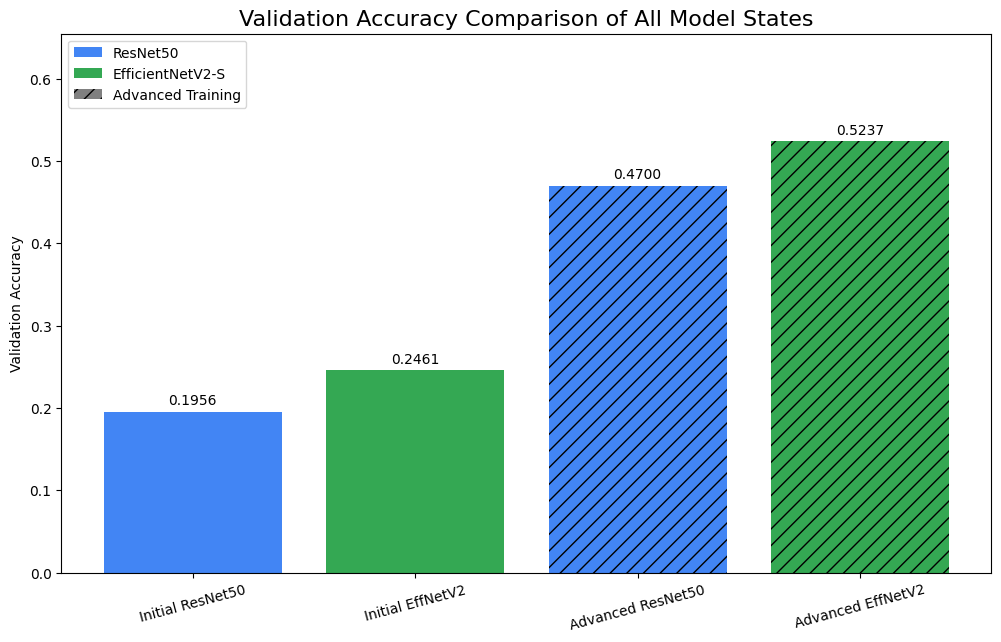



✅ All tasks complete. Files and charts for all four model states have been saved.


In [54]:
# Cell 15: Generate Final Submission Files

import pandas as pd
import numpy as np
import torch
from pathlib import Path
from PIL import Image
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

# === 1. Setup All Final Output Directories ===
print("--- Setting up all final output directories ---")
FinalOutputPath = Path("/content/drive/MyDrive/UP Honours/COS711 - AI/Results/Final outputs/")
FinalOutputPath.mkdir(parents=True, exist_ok=True)

paths = {
    "Initial_ResNet50": FinalOutputPath / "Initial_ResNet50",
    "Initial_EfficientNetV2": FinalOutputPath / "Initial_EfficientNetV2",
    "Advanced_ResNet50": FinalOutputPath / "Advanced_ResNet50",
    "Advanced_EfficientNetV2": FinalOutputPath / "Advanced_EfficientNetV2"
}

for path in paths.values():
    path.mkdir(exist_ok=True)
    print(f"Directory created/ensured: {path}")

# Prediction threshold
PRED_THRESHOLD = 0.5

# 2. Recreate "Initial" Model States ===
# To get the state of the models after their initial single-epoch training (from Cell 13),
# we must re-run that simple training step.
print("\n--- Recreating 'Initial' model states by running one epoch of training ---")
criterion = nn.BCEWithLogitsLoss()

# Recreate Initial ResNet50 state
initial_resnet_model = get_resnet50(nclasses)
optimizer_resnet_initial = AdamW(initial_resnet_model.parameters(), lr=1e-4, weight_decay=1e-5)
# This train_one_epoch is the same function from Cell 13 and is what defines the "initial" state
_ = train_one_epoch(train_loader, initial_resnet_model, optimizer_resnet_initial, criterion, scaler)
print("Recreated state for 'Initial_ResNet50'.")

# Recreate Initial EfficientNetV2 state
initial_efficientnet_model = get_efficientnetv2(nclasses)
optimizer_efficientnet_initial = AdamW(initial_efficientnet_model.parameters(), lr=1e-4, weight_decay=1e-5)
_ = train_one_epoch(train_loader, initial_efficientnet_model, optimizer_efficientnet_initial, criterion, scaler)
print("Recreated state for 'Initial_EfficientNetV2'.")

# The advanced models are already trained and stored in `resnet_model` and `efficientnet_model` from Cell 14.

# 3. Define the File Generation Function ===
def generate_submission_files(model, model_name, output_path):
    """Generates and saves generated_labels.csv and test_labels.csv for a specific model."""
    print(f"\n--- Processing files for model: {model_name} ---")
    model.to(device)
    model.eval()

    # --- Generate 'generated_labels.csv' ---
    unl_dir = BASE / "unl/unl_PNG"
    unl_files = sorted([str(f) for f in unl_dir.glob("*") if f.suffix.lower() in [".png", ".jpg", ".jpeg"]])

    all_probs = []
    with torch.no_grad():
        for i in range(0, len(unl_files), BATCH):
            batch_files = unl_files[i:i+BATCH]
            imgs = [val_transforms(Image.open(f).convert('RGB')) for f in batch_files]
            imgs = torch.stack(imgs).to(device)
            logits = model(imgs)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)

    df_unl_preds_model = pd.DataFrame(np.vstack(all_probs), columns=label_classes)
    df_unl_preds_model['filename'] = unl_files

    generated_labels = []
    for _, row in df_unl_preds_model.iterrows():
        probs = row[label_classes].values
        pred_indices = np.where(probs >= PRED_THRESHOLD)[0]
        labels = [label_classes[i] for i in pred_indices] if len(pred_indices) > 0 else [label_classes[np.argmax(probs)]]

        fname = Path(row['filename']).name
        coords = extract_coords_from_filename(fname)
        coord1, coord2 = coords if coords else ("", "")
        generated_labels.append({'coord1': coord1, 'coord2': coord2, 'labels': ";".join(labels)})

    df_generated = pd.DataFrame(generated_labels)
    df_generated.to_csv(output_path / "generated_labels.csv", index=False)
    print(f"Saved '{model_name}/generated_labels.csv'")

    # --- Generate 'test_labels.csv' ---
    test_csv_path = BASE / "test.csv"
    test_df_coords = pd.read_csv(test_csv_path, header=None, names=['ra', 'dec'])

    test_matches = [img_index.loc[tree.query([row['ra'], row['dec']], k=1)[1], 'filename'] for i, row in test_df_coords.iterrows()]
    test_df_coords['filename'] = test_matches

    test_predictions = []
    with torch.no_grad():
        for _, row in test_df_coords.iterrows():
            img = Image.open(row['filename']).convert('RGB')
            img_tensor = val_transforms(img).unsqueeze(0).to(device)
            logits = model(img_tensor)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            pred_indices = np.where(probs >= PRED_THRESHOLD)[0]
            labels = [label_classes[i] for i in pred_indices] if len(pred_indices) > 0 else [label_classes[np.argmax(probs)]]
            test_predictions.append(";".join(labels))

    test_df_coords['labels'] = test_predictions
    df_test_labels = test_df_coords[['ra', 'dec', 'labels']]
    df_test_labels.to_csv(output_path / "test_labels.csv", index=False)
    print(f"Saved '{model_name}/test_labels.csv'")

# 4. Run File Generation for All Four Model States ===
models_to_process = {
    "Initial_ResNet50": initial_resnet_model,
    "Initial_EfficientNetV2": initial_efficientnet_model,
    "Advanced_ResNet50": resnet_model,
    "Advanced_EfficientNetV2": efficientnet_model
}

for name, model_instance in models_to_process.items():
    generate_submission_files(model_instance, name, paths[name])

# 5. Generate and Save Final Comparison Chart ===
print("\n--- Generating and saving final comparison chart using stored accuracy values ---")

fig, ax = plt.subplots(figsize=(12, 7))
model_names = [
    'Initial ResNet50',
    'Initial EffNetV2',
    'Advanced ResNet50',
    'Advanced EffNetV2'
]
# Use the accuracy variables stored from your notebook cells
accuracies = [
    val_acc_resnet,      # From Cell 13
    val_acc_efficientnet, # From Cell 13
    best_val_r,          # From Cell 14
    best_val_e           # From Cell 14
]

colors = ['#4285F4', '#34A853', '#4285F4', '#34A853']
hatches = ['', '', '//', '//'] # Add hatches to distinguish advanced models

bars = ax.bar(model_names, accuracies, color=colors)

# Apply hatches
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation Accuracy Comparison of All Model States", fontsize=16)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, max(accuracies) * 1.25)
ax.tick_params(axis='x', rotation=15)

# Create a legend for the hatches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4285F4', label='ResNet50'),
                   Patch(facecolor='#34A853', label='EfficientNetV2-S'),
                   Patch(facecolor='grey', hatch='//', label='Advanced Training')]
ax.legend(handles=legend_elements, loc='upper left')

final_chart_path = FinalOutputPath / "all_models_comparison_chart.png"
fig.savefig(final_chart_path, bbox_inches='tight')
print(f"Saved final comparison chart to: {final_chart_path}")
plt.show()

print("\n\n✅ All tasks complete. Files and charts for all four model states have been saved.")